# ML vs LLM

## Chargement des dépendances

In [1]:
# Reload external functions in kernel
%load_ext autoreload

In [34]:
import pandas as pd
from utils.dataframe_utils import get_filling_rate
from utils.ml_utils import clean_text, combine_text_columns
from utils.llm_utils import build_llm_prompt, query_llm, semantic_accuracy
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Chargement du dataset

In [3]:
data = pd.read_parquet("../../datasets/dataset.parquet")

Les types sont mixés sur certaines colonnes, à vérifier lors de l'analyse

## Analyse du dataset

### Découverte rapide

In [4]:
data.head()

,Date received,Tag,Consumer Claim,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2019-05-10,Checking or savings account,<NA>,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,2019-05-10,In progress,Yes,NaN,3238275
1,2019-05-10,Checking or savings account,<NA>,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,2019-05-10,Closed with explanation,Yes,NaN,3238228
2,2019-05-10,Debt collection,<NA>,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,2019-05-10,Closed with explanation,Yes,NaN,3237964
3,2019-05-10,"Credit reporting, credit repair services, or o...",<NA>,NaN,Ad Astra Recovery Services Inc,LA,708XX,NaN,NaN,Web,2019-05-10,Closed with explanation,Yes,NaN,3238479
4,2019-05-10,Checking or savings account,<NA>,NaN,ALLY FINANCIAL INC.,AZ,85205,NaN,NaN,Postal mail,2019-05-10,In progress,Yes,NaN,3238460


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1282355 entries, 0 to 1282354
Data columns (total 15 columns):
 #   Column                        Non-Null Count    Dtype         
---  ------                        --------------    -----         
 0   Date received                 1282355 non-null  datetime64[us]
 1   Tag                           1282355 non-null  category      
 2   Consumer Claim                383564 non-null   string        
 3   Company public response       449082 non-null   category      
 4   Company                       1282355 non-null  string        
 5   State                         1262955 non-null  string        
 6   ZIP code                      1167057 non-null  string        
 7   Tags                          175643 non-null   category      
 8   Consumer consent provided?    690654 non-null   category      
 9   Submitted via                 1282355 non-null  category      
 10  Date sent to company          1282355 non-null  datetime64[us]
 11  Company r

In [6]:
print(f"Dimensions du dataframe : {data.shape[0]} lignes, {data.shape[1]} colonnes")

Dimensions du dataframe : 1282355 lignes, 15 colonnes


### Analyse de la qualité des données

In [7]:
# Get % of non null
stats = data.apply(get_filling_rate)
print(stats)

Date received                   100.000000
Tag                             100.000000
Consumer Claim                   29.910906
Company public response          35.020100
Company                         100.000000
State                            98.487158
ZIP code                         91.008886
Tags                             13.696909
Consumer consent provided?       53.858253
Submitted via                   100.000000
Date sent to company            100.000000
Company response to consumer     99.999454
Timely response?                100.000000
Consumer disputed?               59.928881
Complaint ID                    100.000000
dtype: float64


In [8]:
print(data.nunique())

Date received                      2717
Tag                                  18
Consumer Claim                   366945
Company public response              10
Company                            5275
State                                63
ZIP code                          22591
Tags                                  3
Consumer consent provided?            4
Submitted via                         6
Date sent to company               2666
Company response to consumer          8
Timely response?                      2
Consumer disputed?                    2
Complaint ID                    1282355
dtype: int64


On peut remarquer plusieurs colonnes pouvant être des catégories

#### Colonnes catégories

In [9]:
print(data['Tag'].value_counts())

Tag
Mortgage                                                                        278098
Debt collection                                                                 244873
Credit reporting, credit repair services, or other personal consumer reports    225978
Credit reporting                                                                140432
Credit card                                                                      89190
Bank account or service                                                          86206
Student loan                                                                     51685
Credit card or prepaid card                                                      47653
Checking or savings account                                                      40641
Consumer Loan                                                                    31605
Vehicle loan or lease                                                            11377
Money transfer, virtual currency, or mo

In [10]:
print(data['Company public response'].value_counts())

Company public response
Company has responded to the consumer and the CFPB and chooses not to provide a public response                            311852
Company believes it acted appropriately as authorized by contract or law                                                    61135
Company chooses not to provide a public response                                                                            52473
Company believes the complaint is the result of a misunderstanding                                                           5674
Company disputes the facts presented in the complaint                                                                        5257
Company believes complaint caused principally by actions of third party outside the control or direction of the company      3989
Company believes complaint is the result of an isolated error                                                                3728
Company believes complaint represents an opportunity for improveme

In [11]:
print(data['Tags'].value_counts())

Tags
Servicemember                    84654
Older American                   76981
Older American, Servicemember    14008
Name: count, dtype: int64


In [12]:
print(data['Consumer consent provided?'].value_counts())

Consumer consent provided?
Consent provided        383885
Consent not provided    285087
Other                    20482
Consent withdrawn         1200
Name: count, dtype: int64


In [13]:
print(data['Submitted via'].value_counts())

Submitted via
Web            945329
Referral       173640
Phone           76509
Postal mail     67522
Fax             18972
Email             383
Name: count, dtype: int64


In [14]:
print(data['Company response to consumer'].value_counts())

Company response to consumer
Closed with explanation            993221
Closed with non-monetary relief    158716
Closed with monetary relief         74243
Closed without relief               17868
Closed                              17611
In progress                          9277
Untimely response                    6108
Closed with relief                   5304
Name: count, dtype: int64


In [15]:
print(data['Timely response?'].value_counts())

Timely response?
Yes    1250162
No       32193
Name: count, dtype: int64


In [16]:
print(data['Consumer disputed?'].value_counts())

Consumer disputed?
No     620123
Yes    148378
Name: count, dtype: int64


In [17]:
print(data['Complaint ID'].is_unique)

True


#### Colonnes "string"

In [18]:
data[data['Consumer Claim'].notnull()].head()

,Date received,Tag,Consumer Claim,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
29904,2019-03-23,"Credit reporting, credit repair services, or o...",The Summer of XX/XX/2018 I was denied a mortga...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",IL,<NA>,NaN,Consent provided,Web,2019-03-23,Closed with explanation,Yes,NaN,3189109
30629,2019-03-22,"Credit reporting, credit repair services, or o...",There are many mistakes appear in my report wi...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",VA,220XX,NaN,Consent provided,Web,2019-03-22,Closed with explanation,Yes,NaN,3187982
30735,2019-03-22,"Credit reporting, credit repair services, or o...",There are many mistakes appear in my report wi...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,770XX,NaN,Consent provided,Web,2019-03-22,Closed with explanation,Yes,NaN,3187954
30795,2019-03-22,"Credit reporting, credit repair services, or o...",There are many mistakes appear in my report wi...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,787XX,NaN,Consent provided,Web,2019-03-22,Closed with explanation,Yes,NaN,3188091
30807,2019-03-22,"Credit reporting, credit repair services, or o...",There are many mistakes appear in my report wi...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,951XX,NaN,Consent provided,Web,2019-03-22,Closed with explanation,Yes,NaN,3188119


## Visualisation

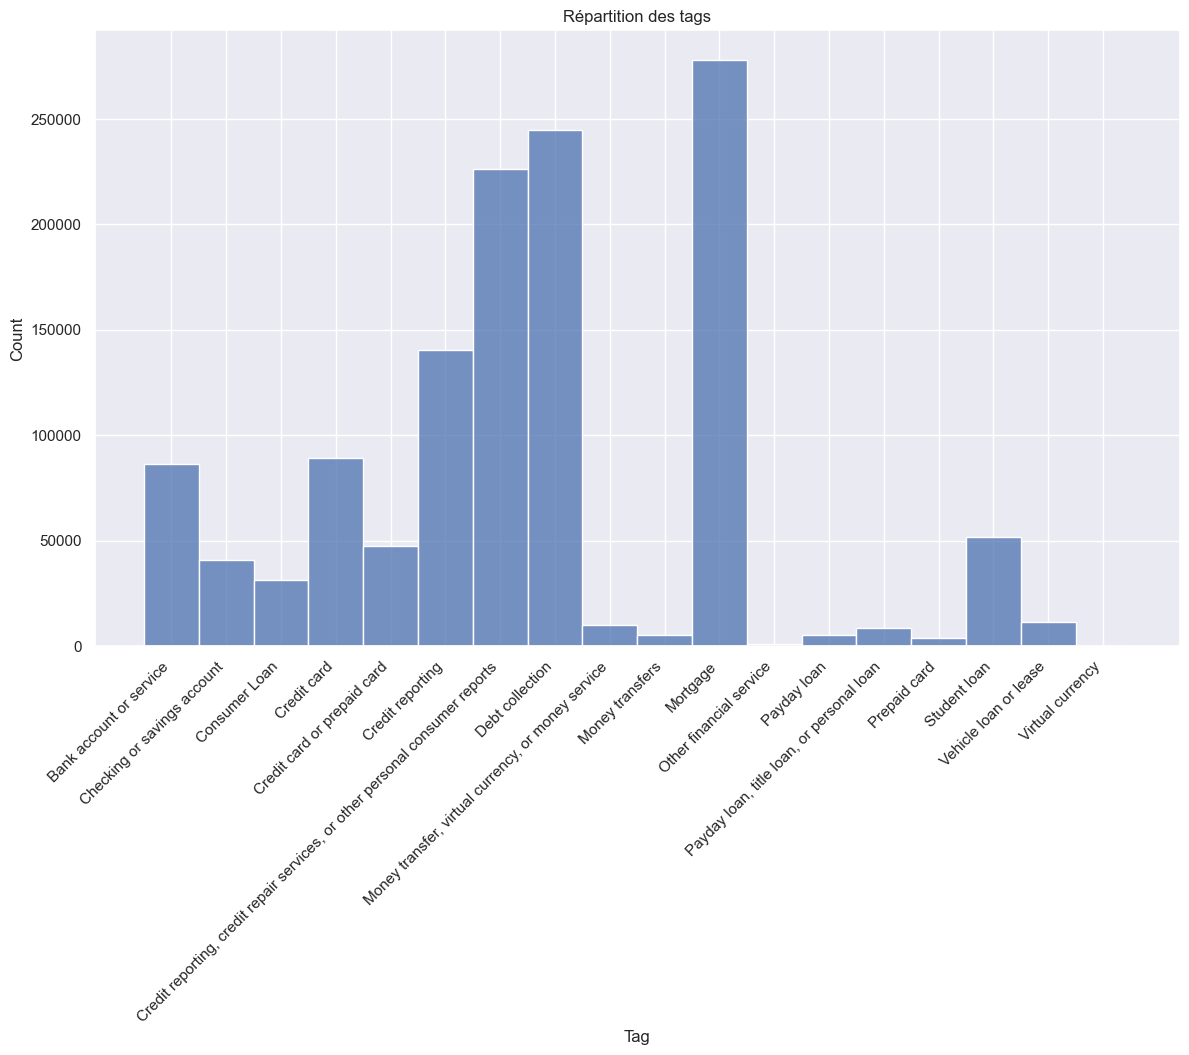

In [19]:
plt.figure(figsize=(14,8))

sns.set_theme(style="darkgrid")
sns.histplot(data=data, x="Tag")

plt.xticks(rotation=45, ha="right")
plt.title("Répartition des tags")
plt.show()

# ML

## Préparation de la data

### Sample

In [20]:
sample_size = 50000

n_per_tag = sample_size // data["Tag"].nunique()

data_sampled = (
    data.groupby("Tag")
    .sample(n=n_per_tag, replace=True, random_state=1357)
    .reset_index(drop=True)
)

data_sampled.head()

,Date received,Tag,Consumer Claim,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2016-06-21,Bank account or service,<NA>,Company has responded to the consumer and the ...,"BANK OF AMERICA, NATIONAL ASSOCIATION",MA,021XX,Older American,NaN,Phone,2016-06-21,Closed with explanation,Yes,Yes,1977427
1,2015-08-28,Bank account or service,<NA>,NaN,TD BANK US HOLDING COMPANY,NY,11210,NaN,NaN,Fax,2015-08-31,Closed with explanation,Yes,Yes,1542691
2,2014-03-06,Bank account or service,<NA>,NaN,WELLS FARGO & COMPANY,NV,89178,NaN,NaN,Web,2014-03-06,Closed with non-monetary relief,Yes,No,746920
3,2017-01-09,Bank account or service,CitiGold Checking Bait and Switch I signed up ...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,760XX,NaN,Consent provided,Web,2017-01-09,Closed with monetary relief,Yes,Yes,2280496
4,2016-01-04,Bank account or service,<NA>,Company chooses not to provide a public response,"SUNTRUST BANKS, INC.",FL,33160,NaN,NaN,Referral,2016-01-07,Closed with explanation,Yes,No,1726470


### Data cleaning

In [21]:
data_sampled["text_raw"] = combine_text_columns(data_sampled)
data_sampled["text_clean"] = clean_text(data_sampled["text_raw"])

### Split data

In [22]:
X = data_sampled.drop(["Tag", "Complaint ID", "text_raw"], axis=1)
y = data_sampled["Tag"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=1357, stratify=y_encoded
)

### Catégorisation pour preprocessors

In [23]:
category_columns = [
    "Company public response",
    "Tags",
    "Consumer consent provided?",
    "Submitted via",
    "Company response to consumer",
    "Timely response?",
    "Consumer disputed?",
]

### Preprocessors

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "tfdif",
            TfidfVectorizer(
                stop_words="english", ngram_range=(1, 2), max_features=10000
            ),
            "text_clean",
        ),
        ("cat_preprocessing", OneHotEncoder(handle_unknown="ignore"), category_columns),
    ]
)

### Pipeline

In [25]:
model_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

## Entrainement et rapport

### Entrainement et prédiction

In [26]:
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

### Rapport

In [27]:
print("=== Classification report (Classic split) ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== Classification report (Classic split) ===
                                                                              precision    recall  f1-score   support

                                                     Bank account or service       0.45      0.59      0.51       555
                                                 Checking or savings account       0.61      0.78      0.68       555
                                                               Consumer Loan       0.66      0.52      0.58       556
                                                                 Credit card       0.52      0.63      0.57       555
                                                 Credit card or prepaid card       0.68      0.77      0.72       556
                                                            Credit reporting       0.96      0.96      0.96       555
Credit reporting, credit repair services, or other personal consumer reports       0.88      0.84      0.86       556
         

# LLM

## Sur des valeurs aléatoires

### Sample

In [47]:
X_llm = X_test.sample(100, random_state=7531)

tags_list = list(le.classes_)

y_test_serie = pd.Series(y_test, index=X_test.index)
true_labels_encoded = y_test_serie.loc[X_llm.index]
true_labels = pd.Series(le.inverse_transform(true_labels_encoded), index=X_llm.index)

### Prédiction ML sur le sample

In [48]:
start_time_ml = time.time()

ml_preds_raw = model_pipeline.predict(X_llm)

total_time_ml = time.time() - start_time_ml

ml_preds = pd.Series(le.inverse_transform(ml_preds_raw), index=X_llm.index)

### Catégorisation avec LLM

In [49]:
print(f"Début des tests LLM en cours")

results = []
start_time_llm = time.time()

for index in tqdm(X_llm.index):
    # Get row
    full_row = data_sampled.loc[index]

    # Prepare prompt
    prompt = build_llm_prompt(full_row, category_columns, tags_list)

    prediction, raw = query_llm(prompt, tags_list, model="llama3:8b", max_retry=5)

    results.append(
        {
            "true_label": true_labels[index],
            "ml_pred": ml_preds[index],
            "ollama_pred": prediction,
            "raw_output": raw,
            "prompt_used": prompt,
        }
    )

total_time_llm = time.time() - start_time_llm
data_sample_llm = pd.DataFrame(results)

Début des tests LLM en cours


100%|██████████| 100/100 [00:21<00:00,  4.55it/s]


In [50]:
data_sample_llm.head(10)

,true_label,ml_pred,ollama_pred,raw_output,prompt_used
0,Credit reporting,Credit reporting,Credit reporting,5,\nROLE: You are a highly precise Customer ...
1,Money transfers,Money transfers,"Money transfer, virtual currency, or money ser...",8,\nROLE: You are a highly precise Customer ...
2,Credit reporting,Credit reporting,Credit reporting,5,\nROLE: You are a highly precise Customer ...
3,Student loan,Student loan,Checking or savings account,1,\nROLE: You are a highly precise Customer ...
4,"Credit reporting, credit repair services, or o...","Credit reporting, credit repair services, or o...",Credit reporting,5,\nROLE: You are a highly precise Customer ...
5,"Payday loan, title loan, or personal loan","Payday loan, title loan, or personal loan","Payday loan, title loan, or personal loan",13,\nROLE: You are a highly precise Customer ...
6,Credit card,Credit card,Credit card,3,\nROLE: You are a highly precise Customer ...
7,Other financial service,Mortgage,Bank account or service,0,\nROLE: You are a highly precise Customer ...
8,Money transfers,Money transfers,"Money transfer, virtual currency, or money ser...",8,\nROLE: You are a highly precise Customer ...
9,Vehicle loan or lease,Vehicle loan or lease,Vehicle loan or lease,16,\nROLE: You are a highly precise Customer ...


In [51]:
print(data_sample_llm['prompt_used'][0])

    
ROLE: You are a highly precise Customer Support Classifier. Your sole purpose is to map customer complaints to a specific predefined tag.

INSTRUCTION :
Analyze the customer complaint and select the most appropriate tag number from the list below.

CONSTRAINTS :
- Output ONLY the tag tex.
- Output must EXACTLY macth one tag number from the list.
- No explanations, no punctuation, no extra words.
- If unsure, pick the closest tag number.
- Never invent a new tag number.

ALLOWED TAGS LIST :
0. Bank account or service
1. Checking or savings account
2. Consumer Loan
3. Credit card
4. Credit card or prepaid card
5. Credit reporting
6. Credit reporting, credit repair services, or other personal consumer reports
7. Debt collection
8. Money transfer, virtual currency, or money service
9. Money transfers
10. Mortgage
11. Other financial service
12. Payday loan
13. Payday loan, title loan, or personal loan
14. Prepaid card
15. Student loan
16. Vehicle loan or lease
17. Virtual currency

CO

### Rapport

In [52]:
ml_accuracy = (data_sample_llm["true_label"] == data_sample_llm["ml_pred"]).mean()
ollama_accuracy = (
    data_sample_llm["true_label"] == data_sample_llm["ollama_pred"]
).mean()

print(f"=== RESULTATS FINAUX ===")
print(f"Accuracy ML : {ml_accuracy}")
print(f"Temps de prédiction ML : {total_time_ml:.2f}s")

print(f"\nAccuracy LLM : {ollama_accuracy}")
print(f"Temps de prédiction LLM : {total_time_llm:.2f}s")

disagreements = data_sample_llm[
    data_sample_llm["ml_pred"] != data_sample_llm["ollama_pred"]
]
print(f"\nNombre de désaccords : {len(disagreements)} sur {len(X_llm)}")

unknown_rate = (data_sample_llm["ollama_pred"] == "UNKNOWN").mean()
print(f"\nTaux d'échec LLM : {unknown_rate}")

print(
    f"Score potentiel du LLM avec une sémantique mieux détaillées : {semantic_accuracy(data_sample_llm)}"
)

=== RESULTATS FINAUX ===
Accuracy ML : 0.7
Temps de prédiction ML : 0.01s

Accuracy LLM : 0.28
Temps de prédiction LLM : 21.96s

Nombre de désaccords : 72 sur 100

Taux d'échec LLM : 0.01
Score potentiel du LLM avec une sémantique mieux détaillées : 0.43


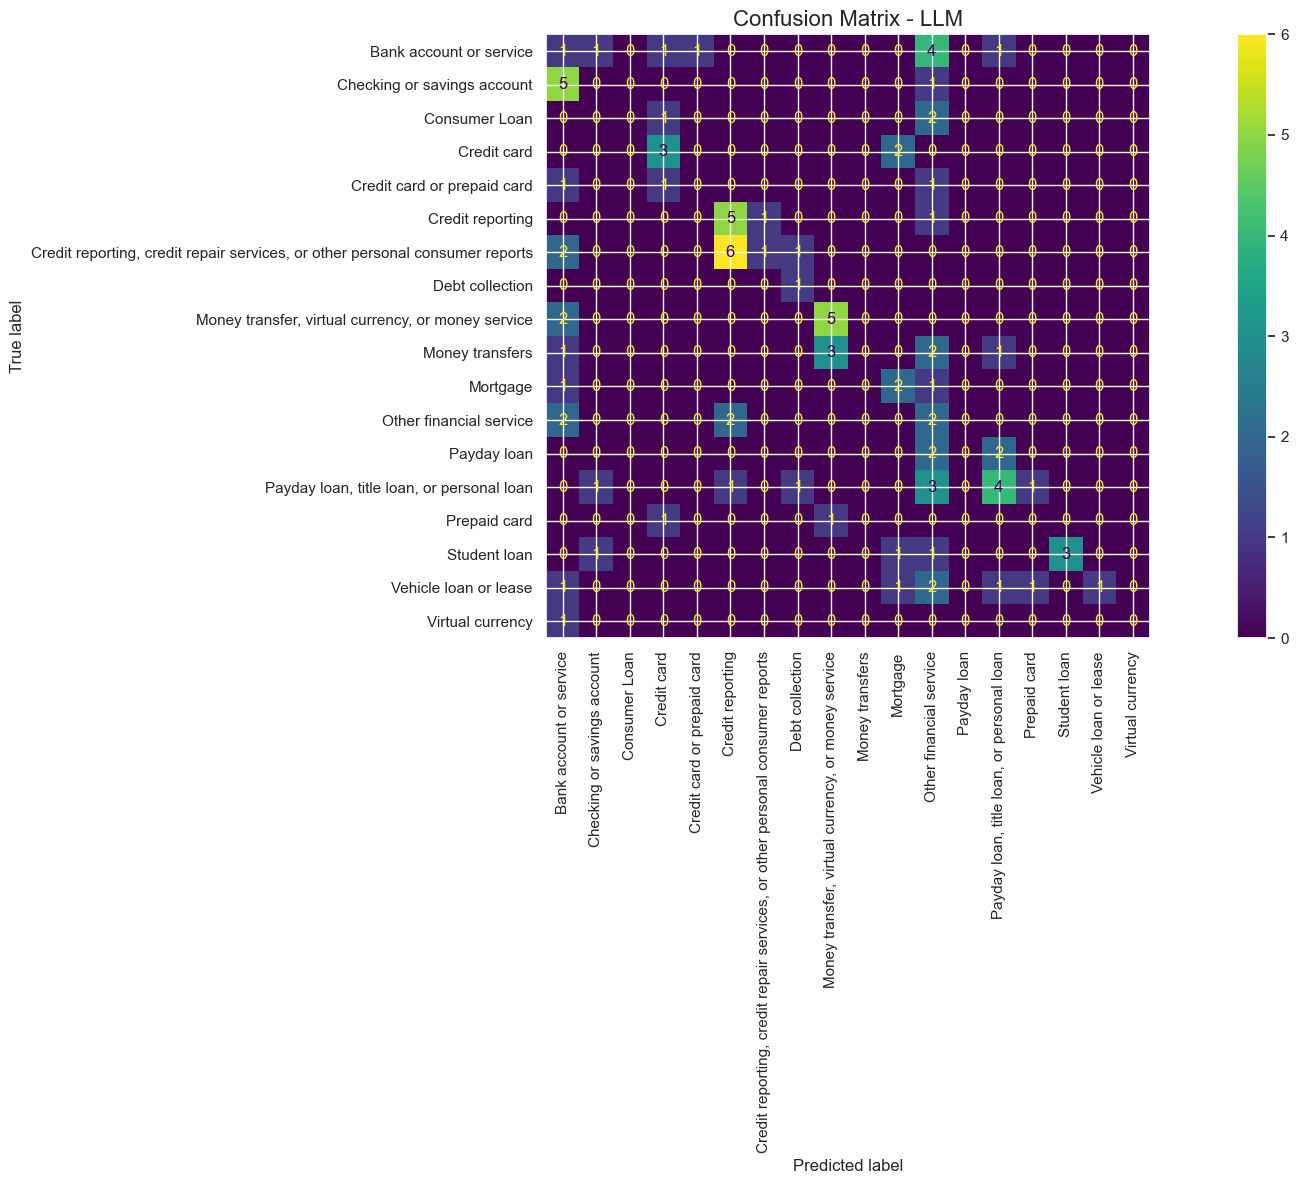

In [53]:
cm_llm = confusion_matrix(
    data_sample_llm["true_label"],
    data_sample_llm["ollama_pred"],
    labels=tags_list
)

fig, ax = plt.subplots(figsize=(20, 12))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm_llm,
    display_labels=tags_list
)

display.plot(ax=ax, xticks_rotation=90)
ax.set_title("Confusion Matrix - LLM", fontsize=16)

plt.tight_layout()
plt.show()